In [34]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from PIL import Image
image_folder = "image/"
image_paths = glob.glob(os.path.join(image_folder, "*.jpg"))

target_size = (512, 512)
images = []
for path in image_paths:
    img = Image.open(path).convert('L')  # grayscale
    img_resized = img.resize(target_size)
    img_array = np.array(img_resized, dtype=float).flatten()  # flatten
    images.append(img_array)

X = np.array(images)

In [35]:
print("Shape của ma trận X:", X.shape)
print("Số hàng (số ảnh):", X.shape[0])
print("Số cột (số pixel/ảnh):", X.shape[1])

Shape của ma trận X: (8, 262144)
Số hàng (số ảnh): 8
Số cột (số pixel/ảnh): 262144


In [36]:
mean_vector = X.mean(axis=0)
print("Shape của vector trung bình:", mean_vector.shape)
X_centered  = X - mean_vector
print("Shape của vector sau khi trừ trung bình:", X_centered.shape)
print("Broadcasting: Python mở rộng mean vector từ (H*W) sang (số ảnh, H*W)")


Shape của vector trung bình: (262144,)
Shape của vector sau khi trừ trung bình: (8, 262144)
Broadcasting: Python mở rộng mean vector từ (H*W) sang (số ảnh, H*W)


In [37]:
def cosine_similarity(X, Y=None):
    if Y is None:
        Y = X
    Xn = X / np.linalg.norm(X, axis=1, keepdims=True)
    Yn = Y / np.linalg.norm(Y, axis=1, keepdims=True)
    return Xn @ Yn.T



In [38]:
sim_matrix = cosine_similarity(X)
print("Shape của ma trận tương đồng", sim_matrix.shape)
print(sim_matrix)

Shape của ma trận tương đồng (8, 8)
[[1.         0.7025502  0.86022873 0.91662281 0.90195227 0.90729821
  0.93716785 0.85745996]
 [0.7025502  1.         0.72960755 0.75469746 0.79693419 0.77386825
  0.75381363 0.81493651]
 [0.86022873 0.72960755 1.         0.8264171  0.88109519 0.82788297
  0.85937202 0.86664562]
 [0.91662281 0.75469746 0.8264171  1.         0.91852331 0.91558549
  0.93439193 0.85835493]
 [0.90195227 0.79693419 0.88109519 0.91852331 1.         0.90157535
  0.91883563 0.91499387]
 [0.90729821 0.77386825 0.82788297 0.91558549 0.90157535 1.
  0.91531948 0.87125199]
 [0.93716785 0.75381363 0.85937202 0.93439193 0.91883563 0.91531948
  1.         0.8772337 ]
 [0.85745996 0.81493651 0.86664562 0.85835493 0.91499387 0.87125199
  0.8772337  1.        ]]


In [39]:
def search(query, top_k=3):
    query_norm = query / np.linalg.norm(query)
    X_norm = X / np.linalg.norm(X, axis=1, keepdims=True)
    similarities = X_norm @ query_norm

    top_indices = np.argsort(similarities)[::-1][:top_k]
    top_scores = similarities[top_indices]

    return top_indices, top_scores

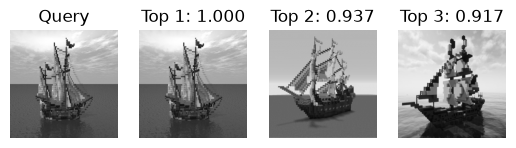

In [40]:
#homework requirement:#
query_img = X[0]
top_indices, top_scores = search(query_img, top_k=3)
plt.subplot(1, 4, 1)
plt.imshow(query_img.reshape(512, 512), cmap='gray')
plt.title('Query')
plt.axis('off')

for i, idx in enumerate(top_indices):
    plt.subplot(1, 4, i+2)
    img = X[idx].reshape(512, 512)
    plt.imshow(img, cmap='gray')
    plt.title(f'Top {i+1}: {top_scores[i]:.3f}')
    plt.axis('off')

plt.show()

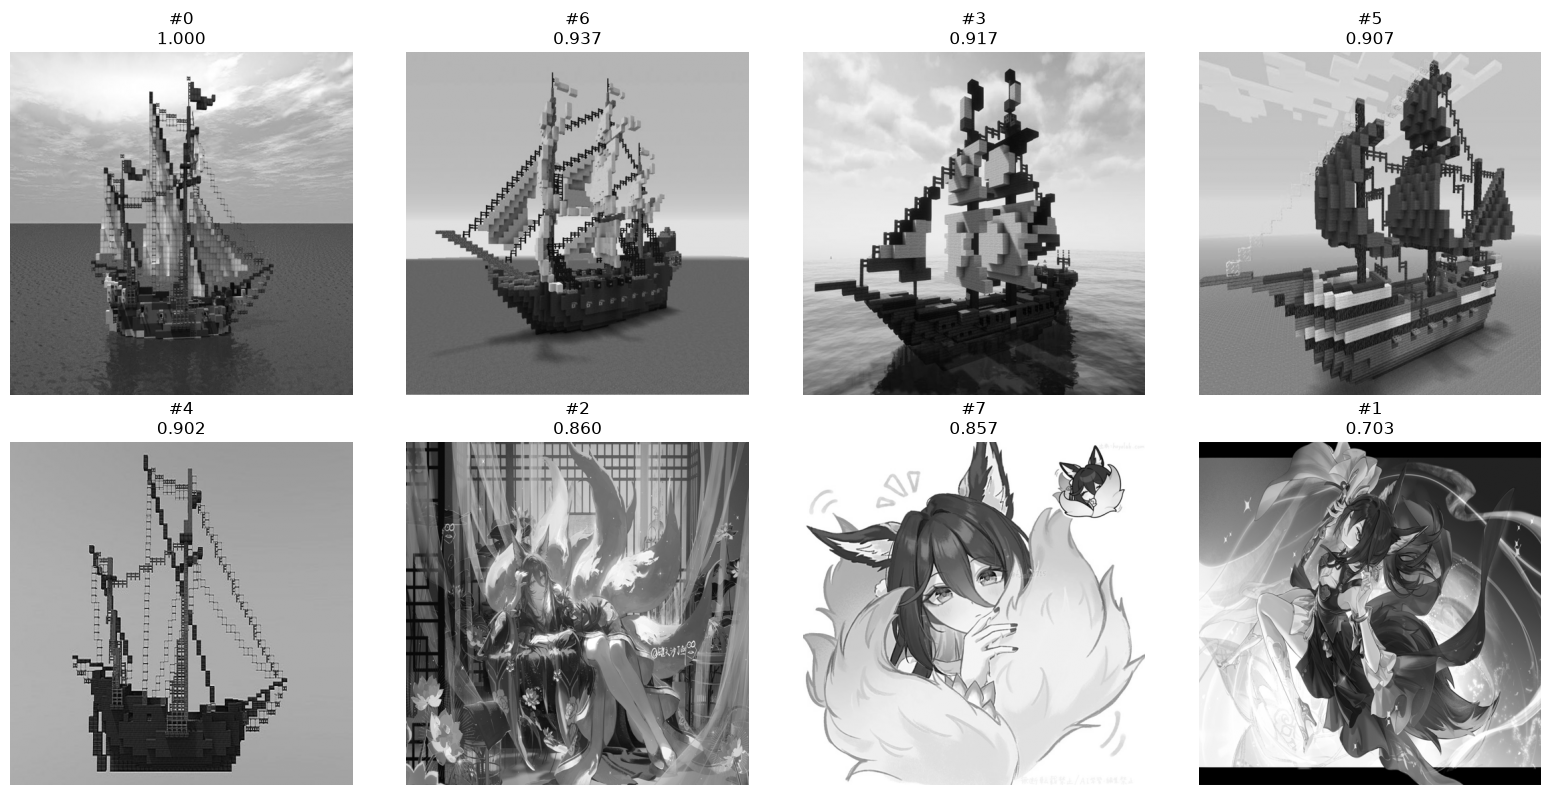

In [41]:
#full 8 images#

indices, scores = search(query_img, top_k=None)

plt.figure(figsize=(16, 8))

for i, (idx, score) in enumerate(zip(indices, scores)):
    plt.subplot(2, 4, i+1)
    img = X[idx].reshape(512, 512)
    plt.imshow(img, cmap='gray')
    plt.title(f'#{idx}\n{score:.3f}')
    plt.axis('off')

plt.tight_layout()
plt.show()

Nhận xét: Về độ hiệu quả, nếu chỉ dùng cosine similar thì similarity chỉ thể hiện được sự tương đồng về độ sáng/tối tổng quát. Khi kiểm tra hình gốc, có thể dự đoán rằng các hình thuyền có similarity trung bình cao với nhau vì background bầu trời, phần chiếm nhiều pixel, đều dùng các sắc độ của màu xanh nhạt.

Cặp giống nhau nhất là 2 chiếc thuyền có background gần giống nhau (có 2 mảng phân biệt rõ ràng, sắc độ của màu xám gần tương tự nhau ở mỗi mảng) có thể dự đoán được đối với trường hợp này, nhưng trong trường hợp tổng quát thì trực giác không đáng tin cậy. Có thể nhận biết ngay #2,#7 và #1 có độ tương đồng thấp, nhưng không thể xác định cặp khác biệt nhất nhất dựa trên trực giác


In [42]:
def rotate_matrix(a):
    return np.array([
        [np.cos(a), -np.sin(a)],
        [np.sin(a), np.cos(a)]
    ])

def scale_matrix(ax, by):
    return np.array([
        [ax, 0],
        [0, by]
    ])

M = X[-1].reshape(512, 512)
U, S, Vt = np.linalg.svd(M, full_matrices=False)
def reconstruct(k):
    return (U[:, :k] * S[:k]) @ Vt[:k, :]

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


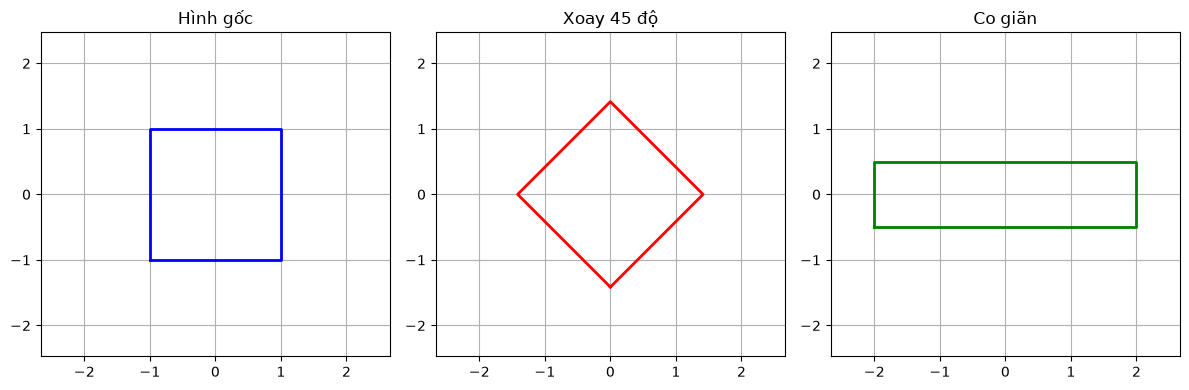

In [43]:
from PIL import Image
test_img = np.array([
    [-1, -1],
    [1, -1],
    [1, 1],
    [-1, 1],
    [-1, -1]
])
R = rotate_matrix(np.pi/4) #xoay 45 do
rotated = test_img @ R.T
S_scale = scale_matrix(2, 0.5) #keo truc x ra 2 lan va truc y ra 0.5 lan
scaled = test_img @ S_scale.T

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(test_img[:, 0], test_img[:, 1], 'b-', linewidth=2)
plt.title('Hình gốc')
plt.axis('equal')
plt.grid(True)
plt.xlim(-3, 3)
plt.ylim(-3, 3)

plt.subplot(1, 3, 2)
plt.plot(rotated[:, 0], rotated[:, 1], 'r-', linewidth=2)
plt.title(f'Xoay {np.degrees(np.pi/4):.0f} độ')
plt.axis('equal')
plt.grid(True)
plt.xlim(-3, 3)
plt.ylim(-3, 3)

plt.subplot(1, 3, 3)
plt.plot(scaled[:, 0], scaled[:, 1], 'g-', linewidth=2)
plt.title('Co giãn')
plt.axis('equal')
plt.grid(True)
plt.xlim(-3, 3)
plt.ylim(-3, 3)

plt.tight_layout()
plt.show()


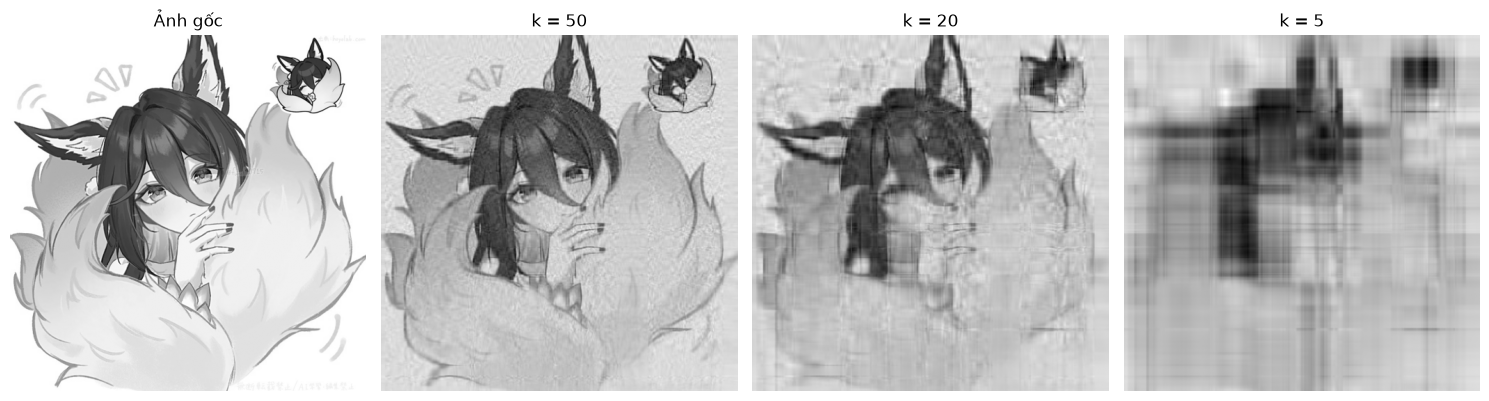

In [44]:
M = X[-1].reshape(512, 512) #scale xuong cho nhẹ
k_values = [5,20,50]
plt.figure(figsize=(15,4))

plt.subplot(1, 4, 1)
plt.imshow(M, cmap='gray')
plt.title('Ảnh gốc')
plt.axis('off')

for i, k in enumerate (reversed(k_values)):
    plt.subplot(1,4,i+2)
    plt.imshow(reconstruct(k), cmap ='gray')
    plt.title(f'k = {k}')
    plt.axis('off')

plt.tight_layout()
plt.show()

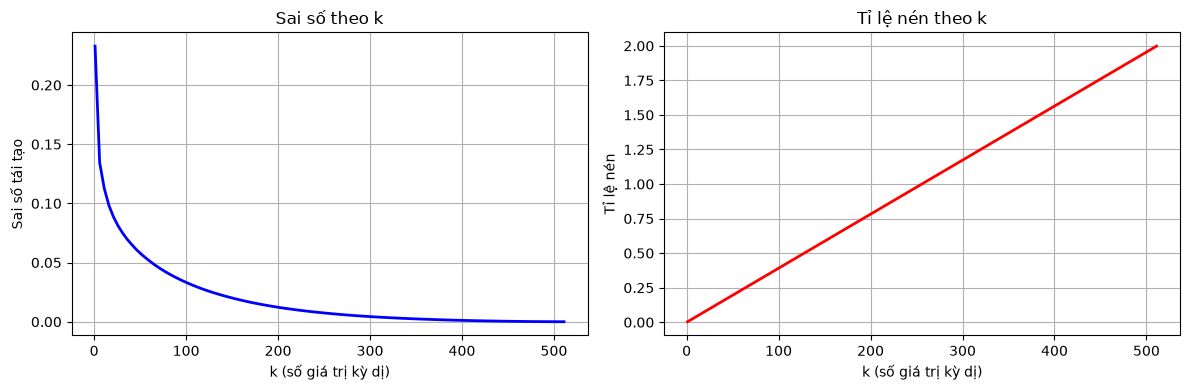

In [45]:
512, 512 == M.shape
totalPixel = 512*512

k_values = range(1, 512, 5)
compress_ratio_arr = []
error_arr = []

for k in k_values:
    compress_ratio = (k*(512+512) + k) / totalPixel
    compress_ratio_arr.append(compress_ratio)

    M_k = reconstruct(k)

    error = np.linalg.norm(M - M_k, 'fro') / np.linalg.norm(M, 'fro')
    error_arr.append(error)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(k_values, error_arr, 'b-', linewidth=2)
plt.xlabel('k (số giá trị kỳ dị)')
plt.ylabel('Sai số tái tạo')
plt.title('Sai số theo k')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_values, compress_ratio_arr, 'r-', linewidth=2)
plt.xlabel('k (số giá trị kỳ dị)')
plt.ylabel('Tỉ lệ nén')
plt.title('Tỉ lệ nén theo k')
plt.grid(True)

plt.tight_layout()
plt.show()


    

Nhận xét: Tùy theo yêu cầu mà ngưỡng chấp nhận được của k sẽ thay đổi. Ở đây, ngưỡng chấp nhận được của sai số theo k là điểm mà đạo hàm bậc hai của hàm này từ dương giảm dần tới 0 (ở đây là tầm 50). Vì đây là hàm giảm nên tăng k sẽ luôn cải thiện chất lượng ảnh, nhưng sẽ tối ưu nhất tại điểm kể trên, sau đó sẽ bị diminishing return.

Vậy, ta có thể làm giảm số lượng đặc trưng xuống đáng kể mà vẫn giữ được phần lớn thông tin, giảm chi phí tính toán, tiết kiệm bộ nhớ và overfitting. Ngoài ra, SVD có thể dùng để tìm ra những thành phần đặc trưng nhất của dữ liệu, làm nền tảng cho PCA.

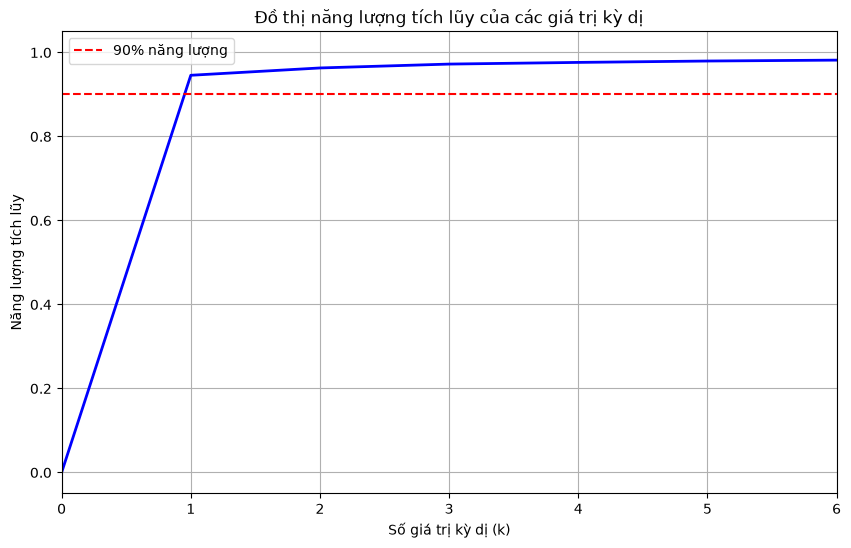

Cần k = 1 để giữ 90% năng lượng


In [46]:
total_energy = np.sum(S**2)
cumulative_energy = np.concatenate([[0], np.cumsum(S**2) / total_energy])

plt.figure(figsize=(10, 6))
plt.plot(cumulative_energy, 'b-', linewidth=2)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% năng lượng')
plt.xlabel('Số giá trị kỳ dị (k)')
plt.ylabel('Năng lượng tích lũy')
plt.title('Đồ thị năng lượng tích lũy của các giá trị kỳ dị')
plt.legend()
plt.grid(True)

plt.xlim(0, 6)

plt.show()

k_90 = np.argmax(cumulative_energy >= 0.90)
print(f"Cần k = {k_90} để giữ 90% năng lượng")